In [17]:
### IMPORTING RELEVANT PACKAGES AND LIBRARIES ###

#import libraries
### from __future__ import division

### from datetime import datetime, timedelta,date
### import pandas as pd
### %matplotlib inline
### from sklearn.metrics import classification_report,confusion_matrix
### import matplotlib.pyplot as plt
### import numpy as np
### import seaborn as sns
### from sklearn.cluster import KMeans


### import plotly as py
### import plotly.offline as pyoff
### import plotly.graph_objs as go

### import xgboost as xgb
### from sklearn.model_selection import KFold, cross_val_score, train_test_split

### import xgboost as xgb

# Standard imports
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import plotly as py
import plotly.offline as pyoff
import plotly.graph_objs as go
import xgboost as xgb
import datetime as dt

# Preprocessing
from __future__ import division
from datetime import datetime, timedelta,date
from matplotlib.pyplot import subplot
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import KFold, cross_val_score, train_test_split

# Models
from sklearn.cluster import KMeans

# Evaluation
from sklearn.metrics import silhouette_score
from sklearn.metrics import classification_report, confusion_matrix


In [2]:
### EXPLORING CUSTOMER SEGMENTATION DATA ###

import pandas as pd

# Load and Prepare Data

try:
    df = pd.read_csv('customer_segmentation.csv', encoding='cp1252')
except FileNotFoundError:
    print("Error: customer_segmentation.csv not found. Please check the file path.")
    exit()

print("Raw Data Table")
print(" ")
print("----------------------------------------------------------------------------------------------------")
df.head() # used to return the first n rows of a DataFrame or Series object. Default value is 5 rows.

Raw Data Table
 
----------------------------------------------------------------------------------------------------


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
### EXPLORING CUSTOMER SEGMENTATION DATA ###
### Step 2: Data Collection & Understanding ###

import pandas as pd

# Load and Explore Data

try:
    df = pd.read_csv('customer_segmentation.csv', encoding='cp1252')
except FileNotFoundError:
    print("Error: customer_segmentation.csv not found. Please check the file path.")
    exit()

print("Number of rows and columns of the data: ")
print(" ")
print(df.shape) # attribute that returns a tuple representing the dimensionality (number of rows and columns) of the DataFrame
print("----------------------------------------------------------------------------------------------------")

print(" ")
print("Summary of Data Type: ")
print(" ")
print(df.info()) # prints a concise summary of a DataFrame to the console. It is a crucial first step in data exploration to quickly assess 
            # the dataset's structure, size, data types, and potential missing values
print("----------------------------------------------------------------------------------------------------")

print(" ")
print("Descriptive Statistics: ")
print(" ")
print(df.describe()) # generates descriptive statistics that summarize the central tendency, dispersion, and shape of a dataset's distribution
print("----------------------------------------------------------------------------------------------------")

print(" ")
print("Count of Missing Values per Column: ")
print(" ")
print(df.isnull().sum()) # used to count the number of missing (NaN or None) values in each column of a DataFrame
print("----------------------------------------------------------------------------------------------------")

print(" ")
print("Count of Distinct Observations per Column: ")
print(" ")
print(df.nunique()) # used to count the number of distinct observations over the requested axis of a DataFrame
print("----------------------------------------------------------------------------------------------------")

print(" ")
# Check each stock code has only one description
print("Different Descriptions Used for each Unique Stock Code: ")
print(" ")
print(df.groupby('StockCode').apply(lambda x: x['Description'].unique())) # This is a common way to see all the different descriptions that have been used
                                                                    # for each unique stock code, which is useful for data cleaning or analysis 
                                                                    # to ensure consistency
print("----------------------------------------------------------------------------------------------------")

print(" ")
# Number of invoices for each country
print("Count of invoices for each country: ")
print(" ")
print(df['Country'].value_counts()) # counts the number of non-missing values for each column within those groups, and 
                                                # selects the 'InvoiceNo' result column. It returns a Series showing the total transaction count 
                                                # per country, with 'Country' as the index



Number of rows and columns of the data: 
 
(541909, 8)
----------------------------------------------------------------------------------------------------
 
Summary of Data Type: 
 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None
----------------------------------------------------------------------------------------------------
 
Descriptive Statistics: 
 
            Quantity      UnitPrice     CustomerID
count  541909.000000  541909

C:\Users\Bernadette Nitura\AppData\Local\Temp\ipykernel_32748\3891633521.py:48: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



RFMT-D Metrics: 
 
            Recency  Frequency  Monetary  Time  Diversity
CustomerID                                               
12346.0         326          1  77183.60     0          1
12747.0           2         11   4196.01   366         42
12748.0           1        209  33719.73   372       1768
12749.0           4          5   4090.88   209        160
12820.0           3          4    942.34   323         55
----------------------------------------------------------------------------------------------------

RFMT-D Scores:
 
            Recency  Frequency  Monetary  Time  Diversity R_score F_score  \
CustomerID                                                                  
12346.0         326          1  77183.60     0          1       1       1   
12747.0           2         11   4196.01   366         42       5       5   
12748.0           1        209  33719.73   372       1768       5       5   
12749.0           4          5   4090.88   209        160       5      

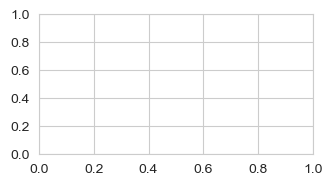

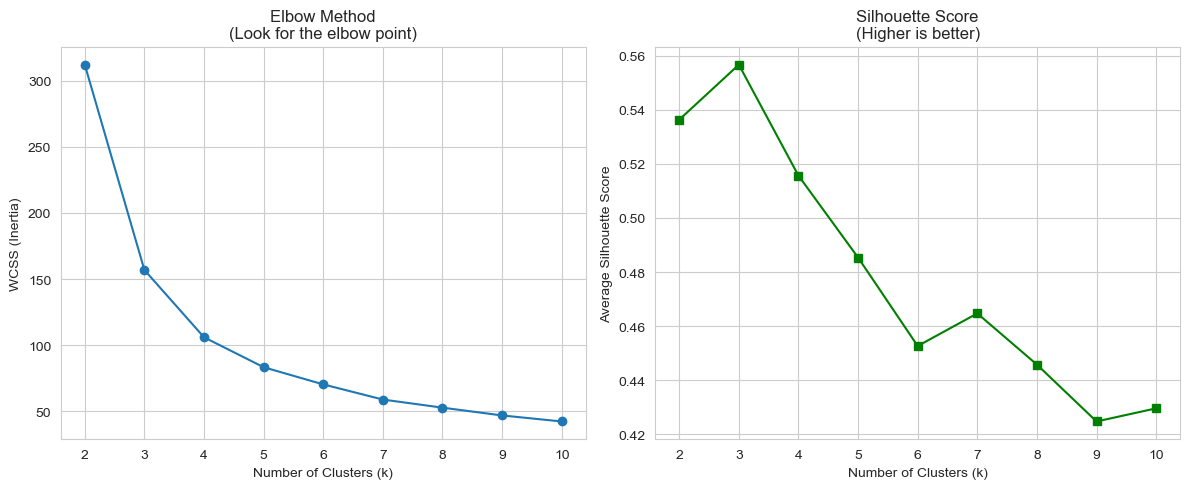


Customer counts per cluster for K=4:
Cluster
0    1181
1     996
3     886
2     857
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------

Applied EDA: HISTOGRAM Distributions
 
----------------------------------------------------------------------------------------------------


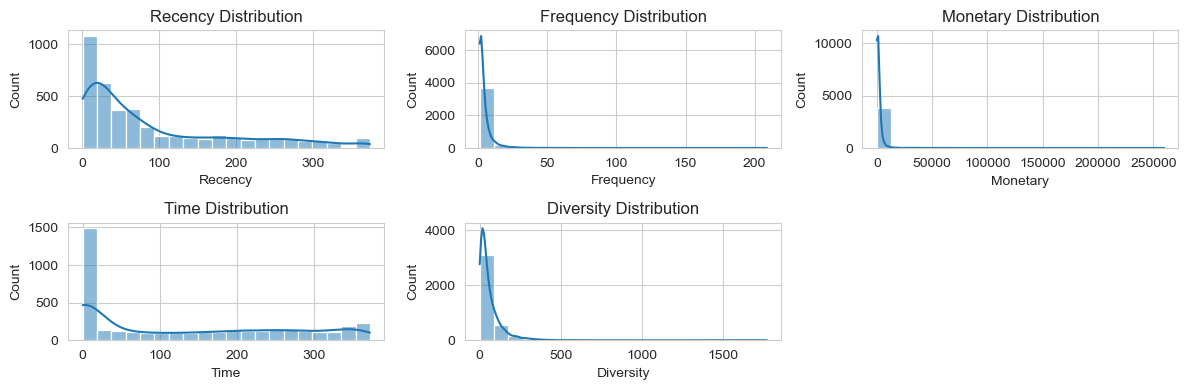


Applied EDA: PAIR PLOT Distributions
 
----------------------------------------------------------------------------------------------------


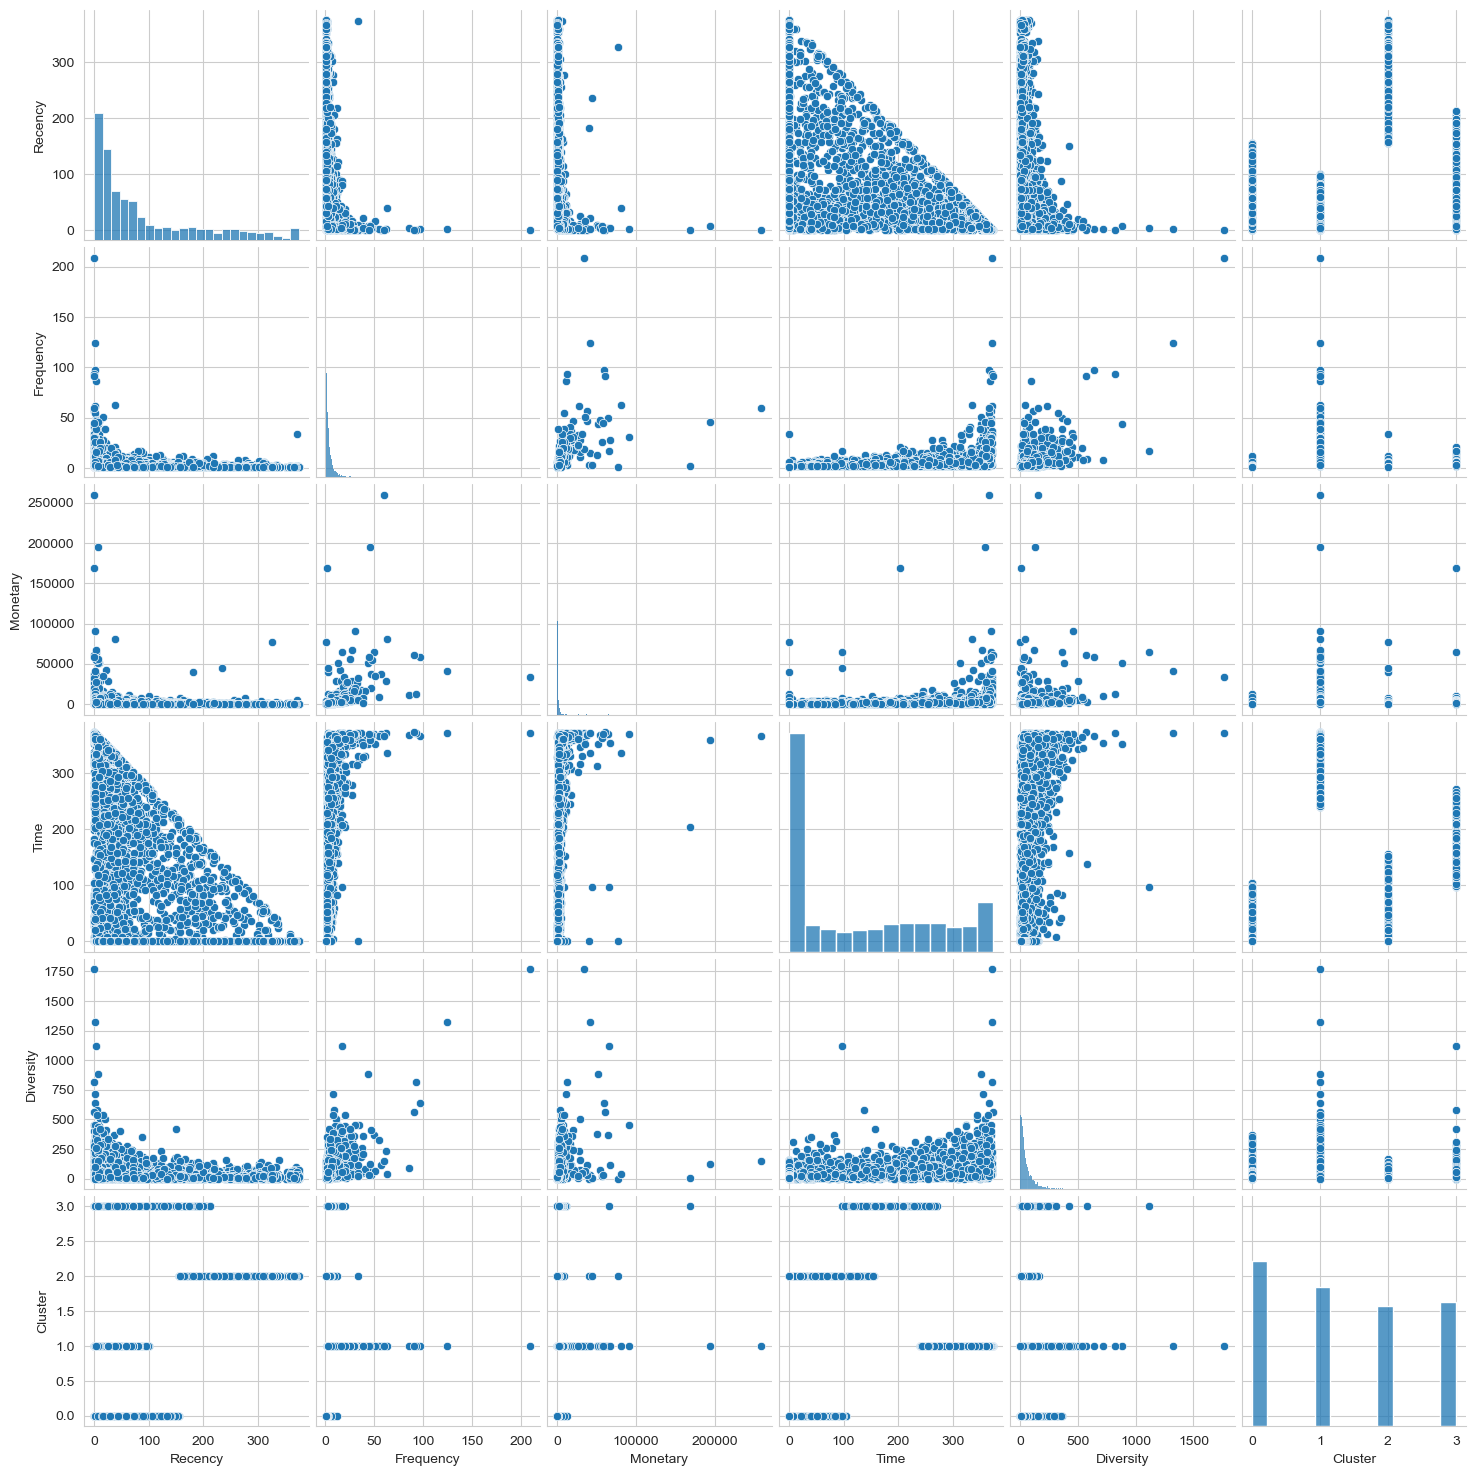


EXPANDED DISTRIBUTIONS FOR CLEARER VISIBILITY
 
----------------------------------------------------------------------------------------------------


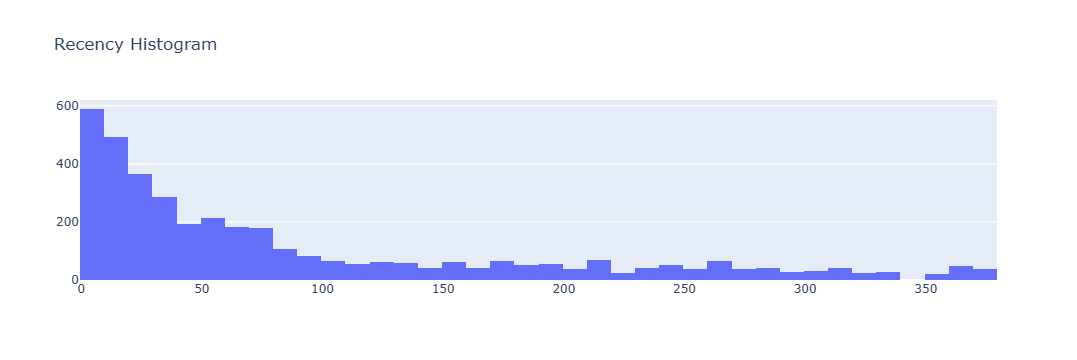

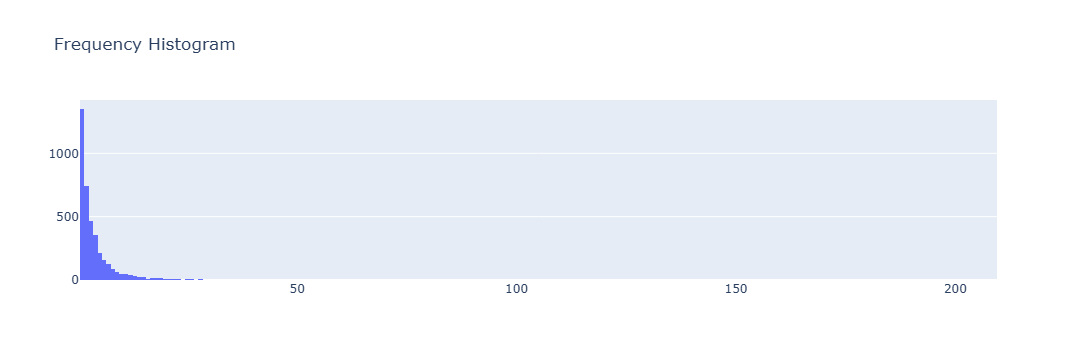

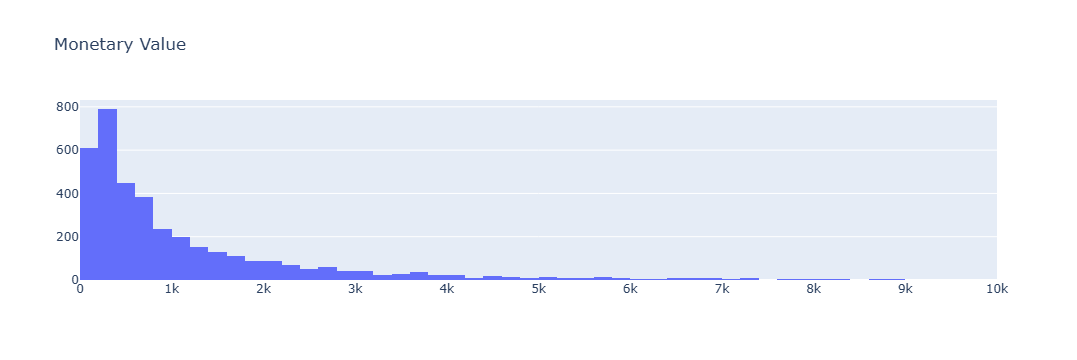

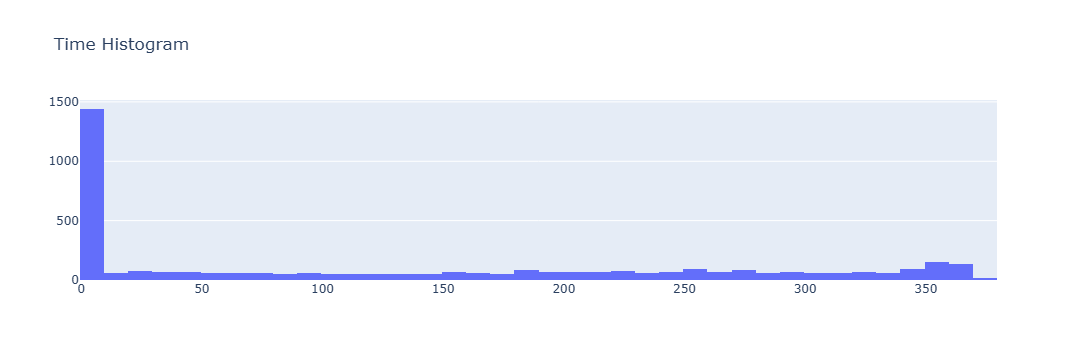

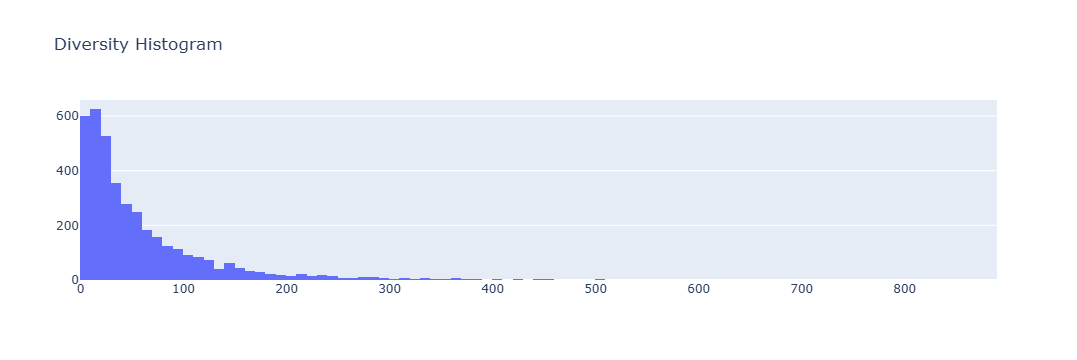

In [29]:
### PROCESSING CUSTOMER SEGMENTATION DATA ###
### Step 3: Data Preprocessing, EDA & Feature Engineering ###

##### Data Cleaning 

# Remove rows with no CustomerID or InvoiceNo
df.dropna(subset=['CustomerID', 'InvoiceNo'], inplace=True)
# Remove cancelled transactions (often indicated by 'C' in InvoiceNo)
df = df[~df['InvoiceNo'].astype(str).str.contains('C')]
# Remove zero or negative quantity and price
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Convert InvoiceDate to datetime object
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Calculate TotalPrice for each transaction
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Filter only UK data which is approximately ~90% of the data
df_uk = df.query("Country=='United Kingdom'").reset_index(drop=True)

##### Calculate RFMT-D Metrics (Recency, Frequency, Monetary, Time and Diversity)

# Define a snapshot date for Recency calculation (one day after the last transaction date in the data)
snapshot_date = df_uk['InvoiceDate'].max() + dt.timedelta(days=1)

# Calculate R, F, M, T and D
rfmtd_df = df_uk.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days), # Days since the last purchase (lower is better)
    Frequency=('InvoiceNo', 'nunique'), # Number of unique invoices/transactions (higher is better)
    Monetary=('TotalPrice', 'sum'), # Total amount spent (higher is better)
    Time=('InvoiceDate', lambda x: (x.max() - x.min()).days), # Number of days between the first and last purchase
    Diversity=('StockCode', 'nunique') # Count unique StockCodes for diversity of products
        
)

# Rename columns for clarity
rfmtd_df.columns = ['Recency', 'Frequency', 'Monetary', 'Time', 'Diversity']

print("RFMT-D Metrics: ")
print(" ")
print(rfmtd_df.head())
print("----------------------------------------------------------------------------------------------------")

##### Assign Scores (using quantiles 1-5)
# Lower recency is better (higher score), so we invert the labels
rfmtd_df['R_score'] = pd.qcut(rfmtd_df['Recency'], 5, labels=[5, 4, 3, 2, 1])
rfmtd_df['F_score'] = pd.qcut(rfmtd_df['Frequency'].rank(method="first"), 5, labels=[1, 2, 3, 4, 5])
rfmtd_df['M_score'] = pd.qcut(rfmtd_df['Monetary'], 5, labels=[1, 2, 3, 4, 5])
rfmtd_df['T_score'] = pd.qcut(rfmtd_df['Time'], q=5, duplicates='drop')
rfmtd_df['D_score'] = pd.qcut(rfmtd_df['Diversity'].rank(method="first"), 5, labels=[1, 2, 3, 4, 5])

# Combine scores to get a total RFMT-D score
rfmtd_df['RFMTD_Score'] = rfmtd_df['R_score'].astype(str) + rfmtd_df['F_score'].astype(str) + rfmtd_df['M_score'].astype(str) + rfmtd_df['T_score'].astype(str) + rfmtd_df['D_score'].astype(str)  

print("\nRFMT-D Scores:")
print(" ")
print(rfmtd_df.head())
print("----------------------------------------------------------------------------------------------------")

##### FEATURE ENGINEERING

# Clustering with K-Means for advanced segmentation
# The scores are often skewed; normalization/scaling is recommended before K-Means
scaler = MinMaxScaler()
rfmtd_scaled = scaler.fit_transform(rfmtd_df[['Recency', 'Frequency', 'Monetary', 'Time', 'Diversity']])

# Determine optimal clusters using the Elbow method or Silhouette Scores 
# Evaluate range of K values
k_range = range(2, 11)
wcss = []               # For Elbow Method
silhouette_scores = []  # For Silhouette Score

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfmtd_scaled)
    wcss.append(kmeans.inertia_)  # Inertia = WCSS
    silhouette_scores.append(silhouette_score(rfmtd_scaled, kmeans.labels_))

print(" ")
print("K-MEANS CLUSTERING")

# Plot Elbow Method
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, wcss, marker='o')
plt.title("Elbow Method\n(Look for the elbow point)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.grid(True)

# Plot Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='s', color='green')
plt.title("Silhouette Score\n(Higher is better)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Average Silhouette Score")
plt.grid(True)

plt.tight_layout()
plt.show()

# After determining optimal K (e.g., K=4) from the plot:
optimal_k = 4 # Replace with your chosen K
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfmtd_df['Cluster'] = kmeans_model.fit_predict(rfmtd_scaled)

print(f"\nCustomer counts per cluster for K={optimal_k}:")
print(rfmtd_df['Cluster'].value_counts())
print("----------------------------------------------------------------------------------------------------")

##### VISUALIZE


print("\nApplied EDA: HISTOGRAM Distributions")
print(" ")
print("----------------------------------------------------------------------------------------------------")

# Set up the visualization environment
sns.set_style("whitegrid")
plt.figure(figsize=(12, 4))

# Plot Recency distribution
subplot(2, 3, 1)
sns.histplot(rfmtd_df['Recency'], bins=20, kde=True)
plt.title('Recency Distribution')

# Plot Frequency distribution
subplot(2, 3, 2)
sns.histplot(rfmtd_df['Frequency'], bins=20, kde=True)
plt.title('Frequency Distribution')

# Plot Monetary distribution
subplot(2, 3, 3)
sns.histplot(rfmtd_df['Monetary'], bins=20, kde=True)
plt.title('Monetary Distribution')

# Plot Time distribution
subplot(2, 3, 4)
sns.histplot(rfmtd_df['Time'], bins=20, kde=True)
plt.title('Time Distribution')

# Plot Time distribution
subplot(2, 3, 5)
sns.histplot(rfmtd_df['Diversity'], bins=20, kde=True)
plt.title('Diversity Distribution')

plt.tight_layout()
plt.show()

print("\nApplied EDA: PAIR PLOT Distributions")
print(" ")
print("----------------------------------------------------------------------------------------------------")

sns.pairplot(rfmtd_df)
plt.show()

print("\nEXPANDED DISTRIBUTIONS FOR CLEARER VISIBILITY")
print(" ")
print("----------------------------------------------------------------------------------------------------")

#plot a RECENCY histogram

plot_data = [
    go.Histogram(
        x=rfmtd_df['Recency']
    )
]

plot_layout = go.Layout(
        title='Recency Histogram'
    )
fig = go.Figure(data=plot_data, layout=plot_layout)
pyoff.iplot(fig)

#plot a FREQUENCY histogram

plot_data = [
    go.Histogram(
        x=rfmtd_df.query('Frequency < 1000')['Frequency']
        
    )
]

plot_layout = go.Layout(
        title='Frequency Histogram'
    )
fig = go.Figure(data=plot_data, layout=plot_layout)
pyoff.iplot(fig)


#plot a MONETARY histogram

plot_data = [
    go.Histogram(
        x=rfmtd_df.query('Monetary < 10000')['Monetary']
    )
]

plot_layout = go.Layout(
        title='Monetary Value'
    )
fig = go.Figure(data=plot_data, layout=plot_layout)
pyoff.iplot(fig)

#plot a TIME histogram

plot_data = [
    go.Histogram(
        x=rfmtd_df['Time']
    )
]

plot_layout = go.Layout(
        title='Time Histogram'
    )
fig = go.Figure(data=plot_data, layout=plot_layout)
pyoff.iplot(fig)

#plot a DIVERSITY histogram

plot_data = [
    go.Histogram(
        x=rfmtd_df.query('Diversity < 1000')['Diversity']
    )
]

plot_layout = go.Layout(
        title='Diversity Histogram'
    )
fig = go.Figure(data=plot_data, layout=plot_layout)
pyoff.iplot(fig)



----------------------------------------------------------------------------------------------------

MODEL COMPARISON 1: K-Means Clustering & Evaluation
 
----------------------------------------------------------------------------------------------------


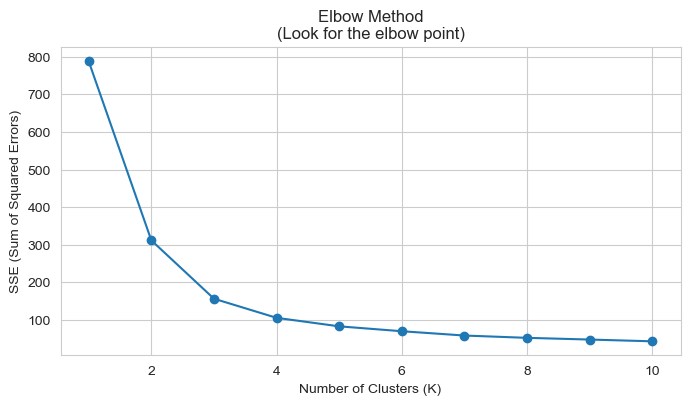

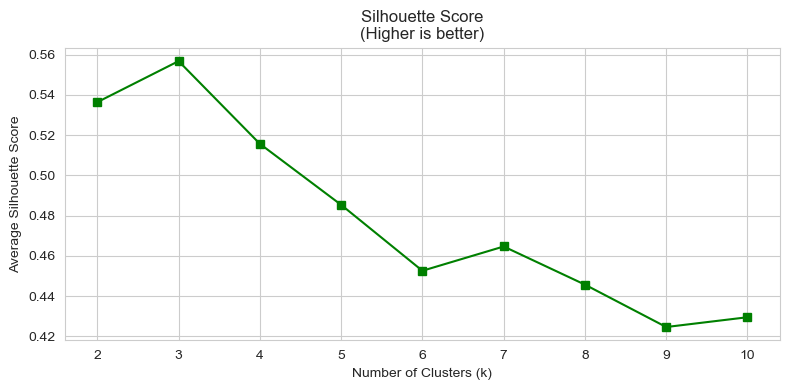

For K=2, Silhouette Score: 0.5363473899288718
For K=3, Silhouette Score: 0.5570192772635395
For K=4, Silhouette Score: 0.5154888088574682
For K=5, Silhouette Score: 0.4852630441722877
For K=6, Silhouette Score: 0.45256929319339506
For K=7, Silhouette Score: 0.4645664984655552
For K=8, Silhouette Score: 0.44498640324102046
For K=9, Silhouette Score: 0.40371134417529314
For K=10, Silhouette Score: 0.40036607216868947
----------------------------------------------------------------------------------------------------

MODEL COMPARISON 2: Hierarchical Clustering & Evaluation
 
----------------------------------------------------------------------------------------------------


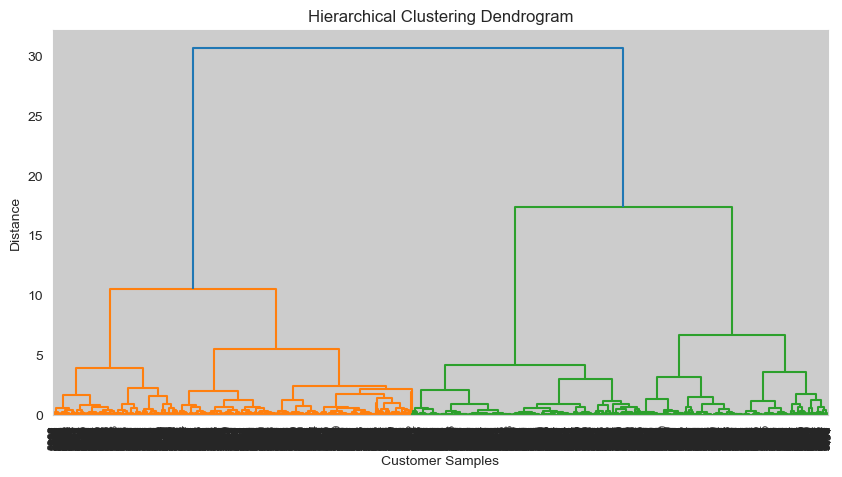

Hierarchical Silhouette Score: 0.49272813140867777
----------------------------------------------------------------------------------------------------

MODEL COMPARISON 3: DBSCAN Clustering & Evaluation
 
----------------------------------------------------------------------------------------------------
DBSCAN found only one cluster or all noise points.
Number of DBSCAN clusters: 1


In [47]:
### MODEL COMPARISON ###

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from matplotlib.pyplot import subplot
import matplotlib.pyplot as plt

##### MODEL 1: K-Means Clustering & Evaluation

print("----------------------------------------------------------------------------------------------------")
print("\nMODEL COMPARISON 1: K-Means Clustering & Evaluation")
print(" ")
print("----------------------------------------------------------------------------------------------------")

# Elbow Method to find optimal K
sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, init='k-means++')
    kmeans.fit(rfmtd_scaled)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
subplot(1, 1, 1)
plt.plot(range(1, 11), sse, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('SSE (Sum of Squared Errors)')
plt.title('Elbow Method\n(Look for the elbow point)')
plt.show()

# Plot Silhouette Scores
plt.figure(figsize=(8, 4))
plt.subplot(1, 1, 1)
plt.plot(k_range, silhouette_scores, marker='s', color='green')
plt.title("Silhouette Score\n(Higher is better)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Average Silhouette Score")
plt.grid(True)

plt.tight_layout()
plt.show()

# Silhouette Score analysis
silhouette_avg = []
for k in range(2, 11): # Silhouette score requires at least 2 clusters
    kmeans = KMeans(n_clusters=k, random_state=42, init='k-means++')
    cluster_labels = kmeans.fit_predict(rfmtd_scaled)
    score = silhouette_score(rfmtd_scaled, cluster_labels)
    silhouette_avg.append(score)
    print(f'For K={k}, Silhouette Score: {score}')

# Choose optimal K based on analysis (e.g., K=4) and fit the model
optimal_k = 4 # Based on visual analysis of plots
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, init='k-means++')
rfmtd_df['KMeans_Cluster'] = kmeans_model.fit_predict(rfmtd_scaled)

print("----------------------------------------------------------------------------------------------------")
print("\nMODEL COMPARISON 2: Hierarchical Clustering & Evaluation")
print(" ")
print("----------------------------------------------------------------------------------------------------")

##### MODEL 2: Hierarchical Clustering & Evaluation

from scipy.cluster.hierarchy import dendrogram, linkage, cut_tree
from sklearn.cluster import AgglomerativeClustering

# Generate the linkage matrix
Z = linkage(rfmtd_scaled, method='ward') # 'ward' minimizes variance within clusters

# Plot the dendrogram (optional, but helpful for visual analysis)
plt.figure(figsize=(10, 5))
dendrogram(Z, leaf_rotation=90., leaf_font_size=8.,)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Customer Samples')
plt.ylabel('Distance')
plt.show()

# Choose number of clusters (e.g., 4, consistent with K-Means) and fit the model
optimal_clusters_h = 4
hierarchical_model = AgglomerativeClustering(n_clusters=optimal_clusters_h, metric='euclidean', linkage='ward')
rfmtd_df['Hierarchical_Cluster'] = hierarchical_model.fit_predict(rfmtd_scaled)

# Evaluate (can use Silhouette score as well)
print(f'Hierarchical Silhouette Score: {silhouette_score(rfmtd_scaled, rfmtd_df["Hierarchical_Cluster"])}')

print("----------------------------------------------------------------------------------------------------")
print("\nMODEL COMPARISON 3: DBSCAN Clustering & Evaluation")
print(" ")
print("----------------------------------------------------------------------------------------------------")

##### MODEL 3: DBSCAN Clustering & Evaluation

from sklearn.cluster import DBSCAN

# Tune parameters (requires experimentation, common to use nearest neighbors plot for eps)
# For this example, parameters are illustrative
dbscan_model = DBSCAN(eps=0.5, min_samples=5) # Tune eps and min_samples
rfmtd_df['DBSCAN_Cluster'] = dbscan_model.fit_predict(rfmtd_scaled)

# DBSCAN assigns noise points the label -1.
# Evaluate (can use Silhouette score for non-noise points)
# Filter out noise points for silhouette calculation if needed
if len(set(rfmtd_df['DBSCAN_Cluster'])) > 1:
    score = silhouette_score(rfmtd_scaled[rfmtd_df['DBSCAN_Cluster'] != -1], rfmtd_df['DBSCAN_Cluster'][rfmtd_df['DBSCAN_Cluster'] != -1])
    print(f'DBSCAN Silhouette Score: {score}')
else:
    print('DBSCAN found only one cluster or all noise points.')

# Analyze the number of clusters found (excluding noise)
num_dbscan_clusters = len(set(rfmtd_df['DBSCAN_Cluster'])) - (1 if -1 in rfmtd_df['DBSCAN_Cluster'] else 0)
print(f'Number of DBSCAN clusters: {num_dbscan_clusters}')


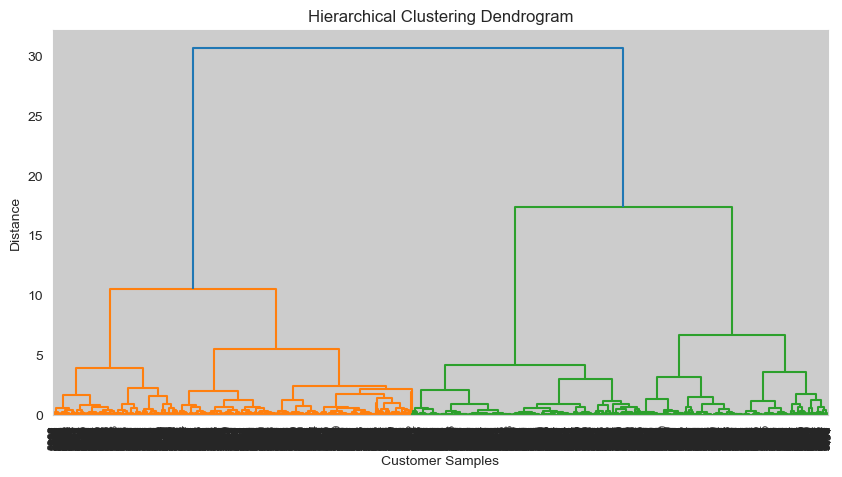

Hierarchical Silhouette Score: 0.49272813140867777


In [42]:
##### MODEL 2: Hierarchical Clustering & Evaluation

from scipy.cluster.hierarchy import dendrogram, linkage, cut_tree
from sklearn.cluster import AgglomerativeClustering

# Generate the linkage matrix
Z = linkage(rfmtd_scaled, method='ward') # 'ward' minimizes variance within clusters

# Plot the dendrogram (optional, but helpful for visual analysis)
plt.figure(figsize=(10, 5))
dendrogram(Z, leaf_rotation=90., leaf_font_size=8.,)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Customer Samples')
plt.ylabel('Distance')
plt.show()

# Choose number of clusters (e.g., 4, consistent with K-Means) and fit the model
optimal_clusters_h = 4
hierarchical_model = AgglomerativeClustering(n_clusters=optimal_clusters_h, metric='euclidean', linkage='ward')
rfmtd_df['Hierarchical_Cluster'] = hierarchical_model.fit_predict(rfmtd_scaled)

# Evaluate (can use Silhouette score as well)
print(f'Hierarchical Silhouette Score: {silhouette_score(rfmtd_scaled, rfmtd_df["Hierarchical_Cluster"])}')



In [43]:
##### MODEL 3: DBSCAN Clustering & Evaluation

from sklearn.cluster import DBSCAN

# Tune parameters (requires experimentation, common to use nearest neighbors plot for eps)
# For this example, parameters are illustrative
dbscan_model = DBSCAN(eps=0.5, min_samples=5) # Tune eps and min_samples
rfmtd_df['DBSCAN_Cluster'] = dbscan_model.fit_predict(rfmtd_scaled)

# DBSCAN assigns noise points the label -1.
# Evaluate (can use Silhouette score for non-noise points)
# Filter out noise points for silhouette calculation if needed
if len(set(rfmtd_df['DBSCAN_Cluster'])) > 1:
    score = silhouette_score(rfmtd_scaled[rfmtd_df['DBSCAN_Cluster'] != -1], rfmtd_df['DBSCAN_Cluster'][rfmtd_df['DBSCAN_Cluster'] != -1])
    print(f'DBSCAN Silhouette Score: {score}')
else:
    print('DBSCAN found only one cluster or all noise points.')

# Analyze the number of clusters found (excluding noise)
num_dbscan_clusters = len(set(rfmtd_df['DBSCAN_Cluster'])) - (1 if -1 in rfmtd_df['DBSCAN_Cluster'] else 0)
print(f'Number of DBSCAN clusters: {num_dbscan_clusters}')


DBSCAN found only one cluster or all noise points.
Number of DBSCAN clusters: 1
